<a href="https://colab.research.google.com/github/ankitkparashar/python/blob/main/CSML/Module4/RNN_LSTM_GRU.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

**Recurrent Neural Network**

In [3]:
from keras.models import Sequential
from keras.layers import Dense, Dropout, SimpleRNN
from sklearn.preprocessing import MinMaxScaler
from sklearn.metrics import mean_squared_error
from sklearn.model_selection import train_test_split
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [4]:
import os

In [5]:
df = pd.read_csv('corona_daily.csv', usecols=[3], engine='python', skipfooter=3)

In [6]:
df.shape

(112, 1)

In [7]:
dataset = df.values
dataset = dataset.astype('float32')

In [8]:
scaler = MinMaxScaler(feature_range=(0, 1))
dataset = scaler.fit_transform(dataset)
train_data, test_data = train_test_split(dataset, train_size=0.80, test_size=0.20, shuffle=False)
print(len(train_data), len(test_data))

89 23


In [9]:
def create_dataset(dataset, look_back=10):
    data_X, data_Y = [], []
    for i in range(len(dataset)-look_back-1):
        a = dataset[i:(i+look_back), 0]
        data_X.append(a)
        data_Y.append(dataset[i + look_back, 0])

    return np.array(data_X), np.array(data_Y)

In [10]:
look_back = 3
train_X, train_Y = create_dataset(train_data, look_back)
test_X, test_Y = create_dataset(test_data, look_back)
print(train_X.shape, train_Y.shape, test_X.shape, test_Y.shape)

(85, 3) (85,) (19, 3) (19,)


In [11]:
X_train = np.reshape(train_X, (train_X.shape[0], 1, train_X.shape[1]))
X_test = np.reshape(test_X, (test_X.shape[0], 1, test_X.shape[1]))

print(X_train.shape, train_Y.shape, X_test.shape, test_Y.shape)

(85, 1, 3) (85,) (19, 1, 3) (19,)


In [12]:
model = Sequential()
model.add(SimpleRNN(3, input_shape=(1, look_back)))
model.add(Dense(1, activation="linear"))
model.compile(loss='mean_squared_error', optimizer='sgd')
model.summary()

/usr/local/lib/python3.12/dist-packages/keras/src/layers/rnn/rnn.py:199: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(**kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ simple_rnn (SimpleRNN)          │ (None, 3)              │            21 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 1)              │             4 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 25 (100.00 B)

 Trainable params: 25 (100.00 B)

 Non-trainable params: 0 (0.00 B)

In [13]:
history = model.fit(X_train, train_Y, validation_data=(X_test, test_Y), epochs=100, batch_size=1, verbose=1)

Epoch 1/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 0.3365 - val_loss: 0.0064
Epoch 2/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0141 - val_loss: 0.0028
Epoch 3/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0035 - val_loss: 4.7184e-04
Epoch 4/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 0.0014 - val_loss: 2.5983e-04
Epoch 5/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 8.4138e-04 - val_loss: 1.3017e-04
Epoch 6/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 9.8351e-04 - val_loss: 1.6705e-04
Epoch 7/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7.0663e-04 - val_loss: 7.6475e-05
Epoch 8/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 0.0011 - val_loss: 3.0500e-04
Epoch 9/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 8.4364e-04 - val_loss: 2.0018e-04
Epoch 10/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 6.6073e-04 - val_loss: 2.2147e-04
Epoch 11/100
85/85 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - loss: 7.0855e-04 - val_loss: 2.4593e-04
Epo

In [14]:
train_predict = model.predict(X_train)
test_predict = model.predict(X_test)

3/3 ━━━━━━━━━━━━━━━━━━━━ 1s 182ms/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 88ms/step


In [15]:
trainPredict = scaler.inverse_transform(train_predict)
trainY = scaler.inverse_transform([train_Y])
testPredict = scaler.inverse_transform(test_predict)
testY = scaler.inverse_transform([test_Y])

In [16]:
trainScore = math.sqrt(mean_squared_error(trainY[0], trainPredict[:,0]))
print('Train Score: %.2f RMSE' % (trainScore))
testScore = math.sqrt(mean_squared_error(testY[0], testPredict[:,0]))
print('Test Score: %.2f RMSE' % (testScore))

Train Score: 257.41 RMSE
Test Score: 250.25 RMSE


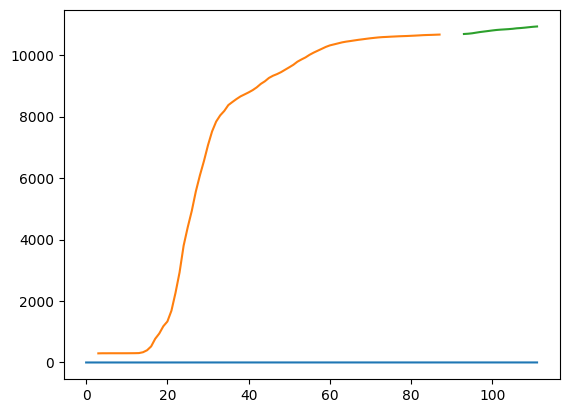

In [18]:
trainPredictPlot = np.empty_like(dataset)
trainPredictPlot[:, :] = np.nan
trainPredictPlot[look_back:len(trainPredict)+look_back, :] = trainPredict
testPredictPlot = np.empty_like(dataset)
testPredictPlot[:, :] = np.nan
testPredictPlot[len(trainPredict)+(look_back+1)*2:len(dataset), :] = testPredict

plt.plot(dataset)
plt.plot(trainPredictPlot)
plt.plot(testPredictPlot)
plt.show()

**LSTM**